# 03: ML-PLAC

Multiplierless piecewise linear approximation of nonlinear 1-to-1 functions.

- Approx $f(x) \approx m_i x + b_i$ on each segment $[x_i, x_{i+1}]$
- Constrain slopes $m_i$ to sums of signed powers of 2 (bit shifts in fixed point)
- $m_i \cdot x$ becomes shifts and adds. No multiplier needed.

e.g. slope $0.75 = 2^0 - 2^{-2}$, so $0.75x = x - (x \gg 2)$

In [1]:
import sys
import pathlib

sys.path.insert(0, str(pathlib.Path("../src")))

In [2]:
import torch
import matplotlib.pyplot as plt
from fp_emulation.mlplac import (
    auto_segment,
    quantize_slope,
    fit_pwl,
    eval_pwl,
    eval_pwl_shifts,
    max_abs_error,
    terms_to_str,
)


def plot_pwl(f, breakpoints, slopes, intercepts, name, mae):
    x = torch.linspace(breakpoints[0], breakpoints[-1], 2000, dtype=torch.float64)
    y_true = f(x)
    y_pwl = eval_pwl(x, breakpoints, slopes, intercepts)

    xn, yn, pn = x.numpy(), y_true.numpy(), y_pwl.numpy()

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(8, 4), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )
    ax1.plot(xn, yn, "k-", lw=1.5, label=name)
    ax1.plot(xn, pn, "r--", lw=1, label=f"PWL ({len(slopes)} seg)")
    for b in breakpoints:
        ax1.axvline(b, color="gray", lw=0.3)
    ax1.legend(fontsize=9)
    ax1.set_ylabel("y")

    ax2.plot(xn, yn - pn, "r-", lw=0.8)
    ax2.axhline(0, color="gray", lw=0.3)
    ax2.set_ylabel("error")
    ax2.set_xlabel("x")
    ax2.set_title(f"MAE = {mae:.2e}", fontsize=9)
    plt.tight_layout()
    plt.show()

## Slope quantization

Greedy: pick the closest power of 2 to the residual, subtract, repeat.

More terms = better approx, but more adders in hw.

In [3]:
for target in [0.762, 0.625, 0.42, -0.18, 1.0]:
    for n in [1, 2, 3]:
        terms, val = quantize_slope(target, n_terms=n)
        err = abs(target - val)
        print(
            f"  {target:+.3f}  n={n}  -> {val:+.4f}  = {terms_to_str(terms):<20s}  err={err:.4f}"
        )
    print()

  +0.762  n=1  -> +1.0000  = x                     err=0.2380
  +0.762  n=2  -> +0.7500  = x - x>>2              err=0.0120
  +0.762  n=3  -> +0.7656  = x - x>>2 + x>>6       err=0.0036

  +0.625  n=1  -> +0.5000  = x>>1                  err=0.1250
  +0.625  n=2  -> +0.6250  = x>>1 + x>>3           err=0.0000
  +0.625  n=3  -> +0.6250  = x>>1 + x>>3           err=0.0000

  +0.420  n=1  -> +0.5000  = x>>1                  err=0.0800
  +0.420  n=2  -> +0.4375  = x>>1 - x>>4           err=0.0175
  +0.420  n=3  -> +0.4219  = x>>1 - x>>4 - x>>6    err=0.0019

  -0.180  n=1  -> -0.1250  = -x>>3                 err=0.0550
  -0.180  n=2  -> -0.1875  = -x>>3 - x>>4          err=0.0075
  -0.180  n=3  -> -0.1797  = -x>>3 - x>>4 + x>>7   err=0.0003

  +1.000  n=1  -> +1.0000  = x                     err=0.0000
  +1.000  n=2  -> +1.0000  = x                     err=0.0000
  +1.000  n=3  -> +1.0000  = x                     err=0.0000



## tanh (manual breakpoints)

Odd function, saturates at $\pm 1$. Steep near 0, flat at tails.

Hand-picked breakpoints: tighter spacing near 0 where curvature is high.

In [4]:
bp_tanh = [-4, -2, -1, -0.5, 0, 0.5, 1, 2, 4]
slopes, intercepts, all_terms = fit_pwl(torch.tanh, bp_tanh, n_terms=2)
mae = max_abs_error(torch.tanh, bp_tanh, slopes, intercepts)

print(f"tanh: {len(slopes)} segments, 2 shift-add terms, MAE = {mae:.4e}")
for i in range(len(slopes)):
    print(
        f"  [{bp_tanh[i]:+5.1f}, {bp_tanh[i + 1]:+5.1f}]  {terms_to_str(all_terms[i]):<20s}  b={intercepts[i]:+.4f}"
    )

tanh: 8 segments, 2 shift-add terms, MAE = 2.4937e-02
  [ -4.0,  -2.0]  x>>6 + x>>9           b=-0.9362
  [ -2.0,  -1.0]  x>>2 - x>>4           b=-0.5990
  [ -1.0,  -0.5]  x>>1 + x>>3           b=-0.1518
  [ -0.5,  +0.0]  x - x>>4              b=-0.0020
  [ +0.0,  +0.5]  x - x>>4              b=+0.0020
  [ +0.5,  +1.0]  x>>1 + x>>3           b=+0.1518
  [ +1.0,  +2.0]  x>>2 - x>>4           b=+0.5990
  [ +2.0,  +4.0]  x>>6 + x>>9           b=+0.9362


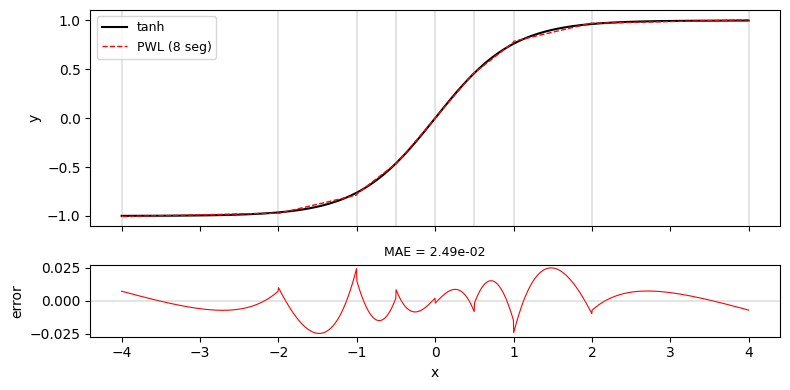

In [5]:
plot_pwl(torch.tanh, bp_tanh, slopes, intercepts, "tanh", mae)

## Bit-shift evaluation

`eval_pwl_shifts` uses `ldexp` (bit shift) instead of float mul. Has same result and maps directly to multiplierless hw: comparators + shifters + adders.

In [6]:
x = torch.linspace(-4, 4, 10000, dtype=torch.float64)
y_mul = eval_pwl(x, bp_tanh, slopes, intercepts)
y_shift = eval_pwl_shifts(x, bp_tanh, all_terms, intercepts)

print(
    f"max diff between mul and shift-only: {torch.max(torch.abs(y_mul - y_shift)).item():.2e}"
)

max diff between mul and shift-only: 0.00e+00


## Automatic segmentation

The [paper](https://www.mdpi.com/2076-3417/12/20/10616) has a self-adaptive segmentor.

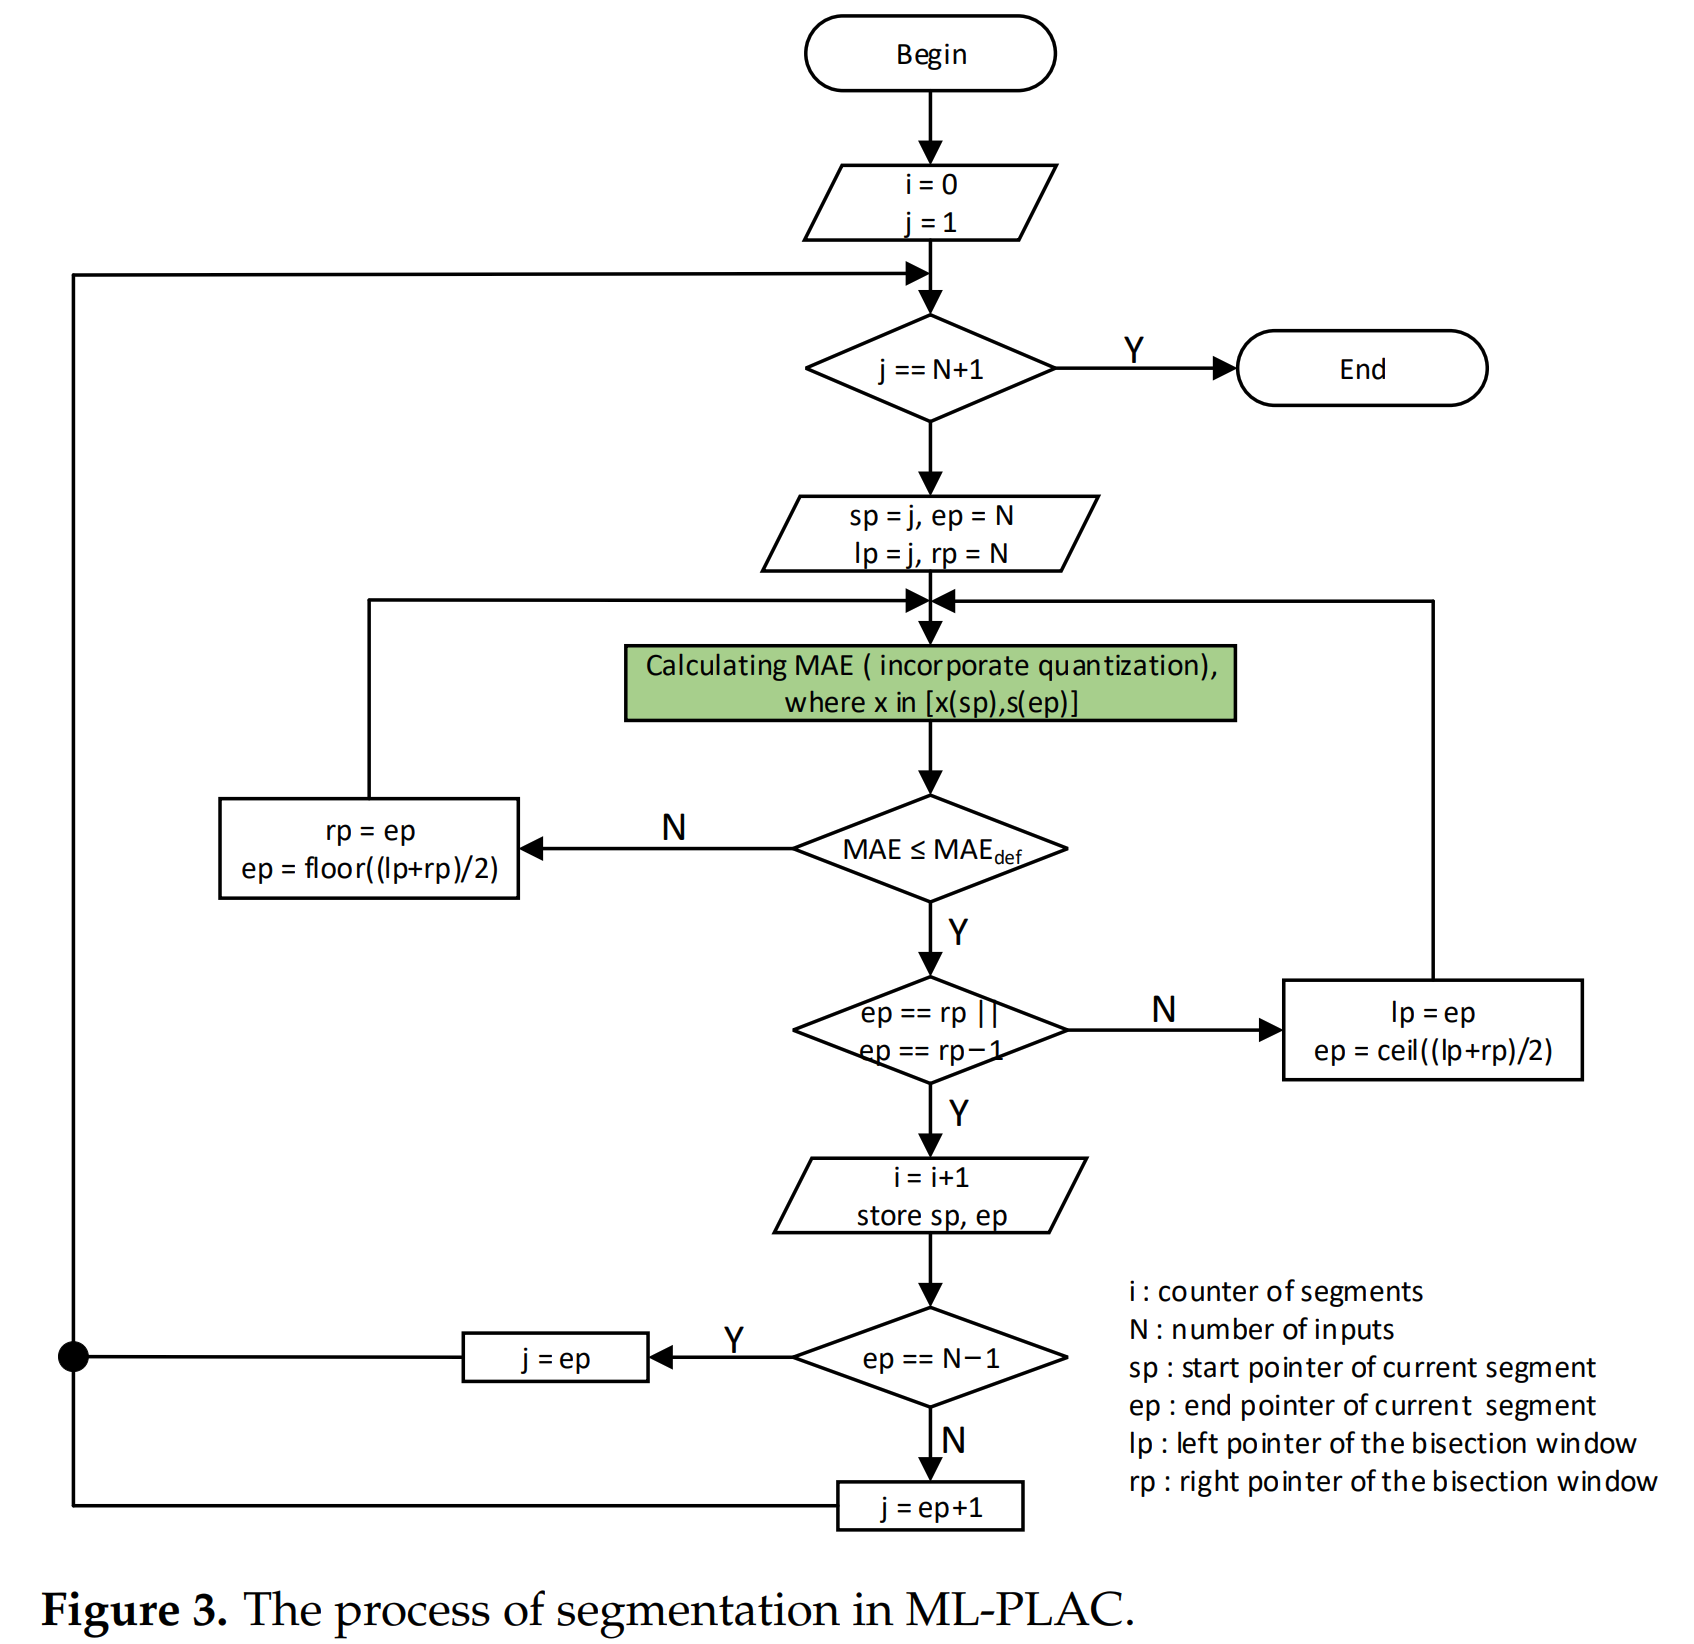

Algorithm: greedy left-to-right. Binary search for the longest segment whose quantized-slope approximation stays under a target MAE. Start a new segment from there. Repeat until the domain is covered.

Given target MAE $\epsilon$, this finds the fewest segments $k$ such that $\max_i |f(x) - (m_i x + b_i)| \leq \epsilon$ on each $[x_i, x_{i+1}]$.

In [7]:
targets = [0.05, 0.01, 0.005, 0.001]

print("tanh auto-segmentation (2 shift-add terms)")
print(f"{'target MAE':>12s}  {'segments':>8s}  {'actual MAE':>12s}")
for t in targets:
    bp = auto_segment(torch.tanh, -4, 4, target_mae=t, n_terms=2)
    s, ic, terms = fit_pwl(torch.tanh, bp, n_terms=2)
    mae = max_abs_error(torch.tanh, bp, s, ic)
    print(f"  {t:>10.4f}  {len(s):>8d}  {mae:>12.4e}")

print()
print("sin auto-segmentation (2 shift-add terms)")
print(f"{'target MAE':>12s}  {'segments':>8s}  {'actual MAE':>12s}")
for t in targets:
    bp = auto_segment(torch.sin, -torch.pi, torch.pi, target_mae=t, n_terms=2)
    s, ic, _ = fit_pwl(torch.sin, bp, n_terms=2)
    mae = max_abs_error(torch.sin, bp, s, ic)
    print(f"  {t:>10.4f}  {len(s):>8d}  {mae:>12.4e}")

tanh auto-segmentation (2 shift-add terms)
  target MAE  segments    actual MAE
      0.0500         5    5.0000e-02
      0.0100        10    1.0000e-02
      0.0050        14    5.0000e-03
      0.0010        35    1.0000e-03

sin auto-segmentation (2 shift-add terms)
  target MAE  segments    actual MAE
      0.0500         7    5.0000e-02
      0.0100        15    1.0000e-02
      0.0050        21    5.0000e-03
      0.0010        55    1.0000e-03


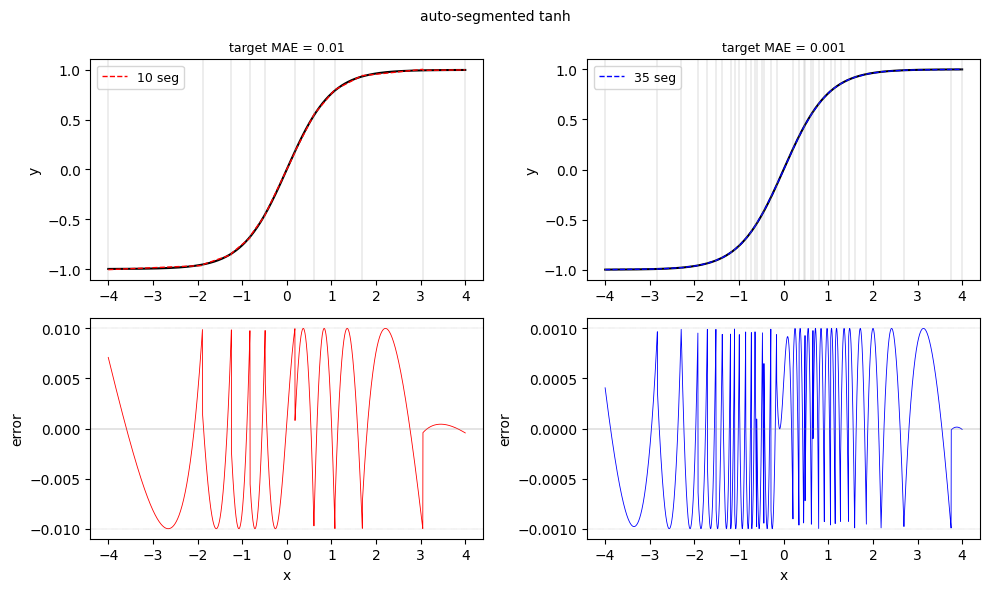

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for col, (target, color) in enumerate([(0.01, "r"), (0.001, "b")]):
    bp = auto_segment(torch.tanh, -4, 4, target_mae=target, n_terms=2)
    s, ic, _ = fit_pwl(torch.tanh, bp, n_terms=2)
    mae = max_abs_error(torch.tanh, bp, s, ic)

    x = torch.linspace(-4, 4, 4000, dtype=torch.float64)
    y_true = torch.tanh(x)
    y_pwl = eval_pwl(x, bp, s, ic)

    xn, yn, pn = x.numpy(), y_true.numpy(), y_pwl.numpy()

    ax1, ax2 = axes[0, col], axes[1, col]
    ax1.plot(xn, yn, "k-", lw=1.5)
    ax1.plot(xn, pn, f"{color}--", lw=1, label=f"{len(s)} seg")
    for b in bp:
        ax1.axvline(b, color="gray", lw=0.2)

    ax1.legend(fontsize=9)
    ax1.set_title(f"target MAE = {target}", fontsize=9)
    ax1.set_ylabel("y")

    ax2.plot(xn, yn - pn, f"{color}-", lw=0.6)
    ax2.axhline(0, color="gray", lw=0.3)
    ax2.axhline(target, color="gray", lw=0.3, ls=":")
    ax2.axhline(-target, color="gray", lw=0.3, ls=":")
    ax2.set_ylabel("error")
    ax2.set_xlabel("x")

plt.suptitle("auto-segmented tanh", fontsize=10)
plt.tight_layout()
plt.show()